In [1]:
# ============================================================
# PARTE 1: DICE por clase (promedio del dataset) — versión ligera
# ============================================================
import json, math, numpy as np
from pathlib import Path
from PIL import Image, ImageDraw
from tqdm import tqdm
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation



In [2]:
DIR_MODA = Path("modanet")

DIR_IMAGENES = DIR_MODA / "images"
DIR_LABELS = DIR_MODA / "annotations-seg"
DIR_PRED_DINO = DIR_MODA / "pred_dino"
DIR_PRED_SEGFORMER = DIR_MODA / "pred_segformer"



!mkdir {DIR_MODA}
!wget "https://www.dropbox.com/scl/fo/g0or9rc44z7ey8oj8b5gv/AJnHmMLpYvYNYj-DK8Vf5oA/annotations-seg.tar?rlkey=l61rkqa63s9kv57bh1tp1oiie&dl=0" -q -O annotations-seg.tar
!wget "https://www.dropbox.com/scl/fo/g0or9rc44z7ey8oj8b5gv/AMvjsHNsh406QE1R7fhEhG8/images_modanet.tar?rlkey=l61rkqa63s9kv57bh1tp1oiie&dl=0" -q -O images_modanet.tar

!tar -xf annotations-seg.tar -C {DIR_MODA}
!tar -xf images_modanet.tar -C {DIR_MODA}



In [3]:
import random

IM_DIR = DIR_IMAGENES
JSON_DIR = DIR_LABELS


IMG_EXTS = (".jpg", ".jpeg", ".png")
json_files = sorted(JSON_DIR.glob("*.json"))

sampled_json_files = random.sample(json_files, 10)

In [4]:
class_names = [
    "background","bag","belt","boots","footwear","outer",
    "dress","sunglasses","pants","top","shorts","skirt",
    "headwear","scarf & tie".replace(" ","")  # evita espacios en nombre
]
NUM_CLASSES = len(class_names)

# ---------- MAPEOS CORREGIDOS ----------
map_pred_modelId_to_final = {
    0:0, 1:12, 2:0, 3:7, 4:9, 5:11, 6:8, 7:6, 8:2, 9:4, 10:4,
    11:0, 12:0, 13:0, 14:0, 15:0, 16:1, 17:13
}
map_gt_jsonId_to_final = {i:i for i in range(NUM_CLASSES)}  # identidad (ajusta si tu JSON usa otros ids)

In [5]:
# ---------- MODELO (usa CPU si tu PC es modesto) ----------


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

SEG_CKPT_PRED = "mattmdjaga/segformer_b2_clothes"
seg_iproc = SegformerImageProcessor.from_pretrained(SEG_CKPT_PRED)
seg_model = SegformerForSemanticSegmentation.from_pretrained(SEG_CKPT_PRED).to(device).eval()

Device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/109M [00:00<?, ?B/s]

In [6]:
# ---------- UTILIDADES ----------
def load_annotations(json_path: Path):
    with open(json_path, 'r') as f:
        anns = json.load(f)
    for a in anns:
        if isinstance(a.get('category_id', None), str):
            try: a['category_id'] = int(a['category_id'])
            except: pass
    return anns

def find_image_for_json(jp: Path) -> Path:
    stem = jp.stem
    for ext in IMG_EXTS:
        p = IM_DIR / f"{stem}{ext}"
        if p.exists(): return p
    raise FileNotFoundError(f"No encontré imagen para {jp.name}")

def polygons_to_mask(img_size_hw, anns, background_id=0):
    H, W = img_size_hw
    mask = Image.new('I', (W, H), color=background_id)
    draw = ImageDraw.Draw(mask)
    for ann in anns:
        cat = int(ann.get('category_id', background_id))
        for poly in ann.get('segmentation', []):
            if not poly: continue
            pts = list(zip(poly[0::2], poly[1::2]))
            draw.polygon(pts, fill=cat)
    return np.array(mask, dtype=np.int64)

def apply_map(mask_np: np.ndarray, mapping: dict, ignore_value: int = -1):
    out = np.full_like(mask_np, ignore_value)
    for k, v in mapping.items():
        out[mask_np == k] = v
    return out

def segformer_predict_ids_final(image_pil: Image.Image) -> np.ndarray:
    """Devuelve máscara en ids FINALES (ModaNet) usando el mapeo de predicción."""
    H, W = image_pil.size[1], image_pil.size[0]
    inputs = seg_iproc(images=image_pil, return_tensors="pt").to(device)
    with torch.no_grad():
        out = seg_model(**inputs)  # logits [1,C,h',w']
    logits_up = F.interpolate(out.logits, size=(H, W), mode="bilinear", align_corners=False)
    pred_model = logits_up.argmax(1).squeeze(0).cpu().numpy().astype(np.int32)  # 0..17
    pred_final = apply_map(pred_model, map_pred_modelId_to_final, ignore_value=-1)
    pred_final[pred_final < 0] = 0  # lo no mapeado -> fondo
    return pred_final

def dice_per_class_image(gt_final: np.ndarray, pred_final: np.ndarray, K: int):
    """Dice solo en clases presentes en el GT (las ausentes quedan NaN)."""
    scores = np.full((K,), np.nan, dtype=np.float32)
    for c in range(K):
        gt_c = (gt_final == c)
        if gt_c.sum() == 0:
            continue
        pred_c = (pred_final == c)
        inter = np.logical_and(gt_c, pred_c).sum()
        total = gt_c.sum() + pred_c.sum()
        scores[c] = (2.0 * inter / total) if total > 0 else 0.0
    return scores

def plot_bars(values, labels, title="Dice por clase (promedio)"):
    x = np.arange(len(values))
    plt.figure(figsize=(10,5))
    plt.bar(x, values)
    plt.xticks(x, labels, rotation=45, ha='right')
    plt.ylim(0,1)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [7]:
# ---------- DRIVER (procesa solo las primeras N imágenes) ----------
def run_partial_dice(MAX_IMAGES=10):
    dice_list = []
    files = json_files[:MAX_IMAGES]
    for jp in tqdm(files, desc=f"Dice sobre {len(files)} imágenes"):
        # 1) Imagen + GT desde JSON
        img_path = find_image_for_json(jp)
        img = Image.open(img_path).convert("RGB")
        anns = load_annotations(jp)
        H, W = img.size[1], img.size[0]
        gt_json = polygons_to_mask((H, W), anns, background_id=0)            # ids JSON
        gt_final = apply_map(gt_json, map_gt_jsonId_to_final, ignore_value=-1) # ids finales
        gt_final[gt_final < 0] = 0

        # 2) Predicción del modelo → ids finales
        pred_final = segformer_predict_ids_final(img)

        # 3) Dice por imagen (solo clases presentes en GT)
        dice_img = dice_per_class_image(gt_final, pred_final, NUM_CLASSES)
        dice_list.append(dice_img)

    dice_avg = np.nanmean(np.vstack(dice_list), axis=0)  # promedio ignorando NaN
    print("\nDice promedio por clase:")
    for name, val in zip(class_names, dice_avg):
        print(f"{name:12s}: {val:.3f}")
    plot_bars(dice_avg, class_names, title=f"Dice por clase (promedio {len(files)} imgs)")

Dice sobre 10 imágenes: 100%|██████████| 10/10 [00:47<00:00,  4.72s/it]
/tmp/ipython-input-2887698330.py:22: RuntimeWarning: Mean of empty slice
  dice_avg = np.nanmean(np.vstack(dice_list), axis=0)  # promedio ignorando NaN



Dice promedio por clase:
background  : 0.989
bag         : 0.650
belt        : 0.000
boots       : 0.000
footwear    : 0.707
outer       : 0.000
dress       : 0.447
sunglasses  : 0.749
pants       : 0.969
top         : 0.831
shorts      : 0.000
skirt       : 0.763
headwear    : nan
scarf&tie   : 0.000


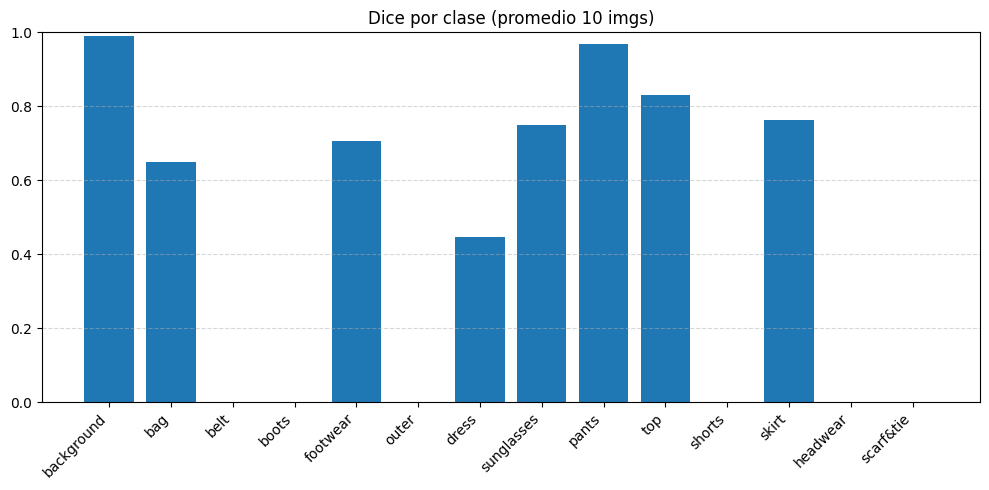

In [8]:
if device == 'cpu':
  run_partial_dice(MAX_IMAGES=len(sampled_json_files))
else:
  run_partial_dice(MAX_IMAGES=len(json_files))

In [9]:
import os, sys, math, shutil, subprocess
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
import torchvision.transforms as T
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.pyplot as plt

from transformers import SegformerModel, SegformerImageProcessor

DINO_REPO_DIR     = "./dinov3"      # repo local
DINO_WEIGHTS_PATH = "./dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth"  # tu .pth en el cwd
GDOWN_FILE_ID     = "1Fznrc_pDwp7iaUBhAoWUKPI1vsGpHy8m"               # opcional, si descargas
IMG_SIZE          = 518


In [10]:
# ---------------------------------
# Utilidades de instalación/descarga
# ---------------------------------
def _run_quiet(cmd):
    subprocess.check_call(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT)

def ensure_repo_and_tools(try_clone=True, try_install=True):
    """Asegura repo DINOv3 y dependencias mínimas en el cwd."""
    if try_install:
        # torchmetrics es dependencia usada por el repo
        _run_quiet([sys.executable, "-m", "pip", "install", "-q", "torchmetrics", "gdown"])
    if not os.path.isdir(DINO_REPO_DIR) and try_clone:
        _run_quiet(["git", "clone", "https://github.com/facebookresearch/dinov3.git", DINO_REPO_DIR])

def maybe_download_weights(weights_path=DINO_WEIGHTS_PATH, gdown_id=GDOWN_FILE_ID):
    """Descarga pesos con gdown si no existen (al cwd) y valida que no sea HTML."""
    if os.path.isfile(weights_path):
        return
    try:
        _run_quiet(["gdown", "--fuzzy", "--id", gdown_id, "-O", weights_path])
    except Exception:
        print("[setup] No se pudieron descargar pesos automáticamente. Si ya los tienes, súbelos al cwd.")
        return

In [11]:
# -----------------------------
# Carga de DINOv3 (manual, robusta)
# -----------------------------
def _verify_and_load_checkpoint(path):
    """torch.load para validar que el archivo es un checkpoint PyTorch real (no HTML/truncado)."""
    try:
        obj = torch.load(path, map_location="cpu")
        return obj
    except Exception as e:
        raise RuntimeError(
            f"[DINOv3] El archivo de pesos no es válido. "
            f"¿Descarga incompleta/HTML de Drive? Detalle: {e}"
        )

def _extract_state_dict(obj):
    """Obtiene un state_dict desde distintos formatos comunes."""
    if isinstance(obj, dict):
        for k in ("state_dict", "model"):
            if k in obj and isinstance(obj[k], dict):
                return obj[k]
    return obj  # podría ser ya el state_dict

def _strip_prefixes(sd, prefixes=("module.", "backbone.", "model.")):
    """Elimina prefijos típicos en las keys del state_dict."""
    out = {}
    for k, v in sd.items():
        kk = k
        for p in prefixes:
            if kk.startswith(p):
                kk = kk[len(p):]
        out[kk] = v
    return out

def _build_vit_b16(img_size=IMG_SIZE):
    """Crea el ViT-B/16 del repo DINOv3."""
    sys.path.insert(0, os.path.abspath(DINO_REPO_DIR))
    from dinov3.models.vision_transformer import vit_base
    # Hiperparámetros habituales en DINOv3 ViT-B/16
    model = vit_base(patch_size=16, img_size=img_size, init_values=1.0, qkv_bias=True)
    return model

def load_dino_small(device=device, auto_clone=True, auto_download=True):
    """
    Devuelve: (modelo_dinov3.eval().to(device), transform_preproc)
    - Descarga/valida repo y pesos en el cwd.
    - Carga manual del state_dict (robusto a formatos).
    """
    ensure_repo_and_tools(try_clone=auto_clone, try_install=True)
    maybe_download_weights(DINO_WEIGHTS_PATH) if auto_download else None

    # Validar checkpoint y extraer state_dict
    ckpt = _verify_and_load_checkpoint(DINO_WEIGHTS_PATH)
    sd   = _extract_state_dict(ckpt)
    sd   = _strip_prefixes(sd)

    # Construir y cargar modelo
    model = _build_vit_b16(img_size=IMG_SIZE)
    missing, unexpected = model.load_state_dict(sd, strict=False)
    if (len(missing) + len(unexpected)) > 0:
        # Informativo: suele haber llaves de cabezas que no se usan
        print(f"[DINOv3] Missing: {len(missing)} | Unexpected: {len(unexpected)}")

    model = model.to(device).eval()

    # Preprocesamiento (ImageNet mean/std + resize a 518)
    pre = T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    return model, pre


In [12]:
# -----------------------------------------
# Extracción de tokens (sin CLS) para DINOv3
# -----------------------------------------
def get_vit_tokens(model, img_t):
    """
    Devuelve: tokens [B,P,C] (sin CLS), (ph,pw), C.
    Intenta usar forward_features del repo DINOv3.
    """
    with torch.no_grad():
        out = model.forward_features(img_t)  # DINOv3 expone este método
        # Casos comunes:
        if isinstance(out, dict):
            if "x_norm_patchtokens" in out:   # [B,P,C]
                tokens = out["x_norm_patchtokens"]
            elif "tokens" in out:              # [B,N,C] (puede incluir CLS)
                tokens = out["tokens"]
            else:
                # Tomar el tensor 3D más grande
                cands = [v for v in out.values() if isinstance(v, torch.Tensor) and v.ndim == 3]
                if not cands:
                    raise RuntimeError("[DINOv3] forward_features no retornó tokens 3D.")
                tokens = max(cands, key=lambda t: t.shape[1])
        elif isinstance(out, torch.Tensor):
            tokens = out
        else:
            raise RuntimeError("[DINOv3] forward_features devolvió un tipo inesperado.")

        B, N, C = tokens.shape
        # Heurística CLS: si N-1 es cuadrado perfecto, asumimos CLS en posición 0
        if (N - 1) > 0 and int(round(math.sqrt(N - 1)))**2 == (N - 1):
            ph = pw = int(round(math.sqrt(N - 1)))
            tokens = tokens[:, 1:, :]  # quitar CLS
        else:
            ph = pw = int(round(math.sqrt(N)))
        return tokens, (ph, pw), C


In [13]:
# -----------------------------------------
# SegFormer encoder -> tokens plana rejilla
# -----------------------------------------
def segformer_encoder_and_tokens(ckpt, device=device, image_pil=None):
    iproc = SegformerImageProcessor.from_pretrained(ckpt)
    enc   = SegformerModel.from_pretrained(ckpt).to(device).eval()
    inputs = iproc(images=image_pil, return_tensors="pt")
    px = inputs["pixel_values"].to(device)
    with torch.no_grad():
        out = enc(pixel_values=px)
    feats = out.last_hidden_state  # [1,C,ph,pw]
    B,C,ph,pw = feats.shape
    tokens = feats.permute(0,2,3,1).reshape(B, ph*pw, C)  # [1,P,C]
    return tokens, (ph,pw), C


In [14]:
# -----------------------------------------
# Helpers: region mean + UMAP (tu misma API)
# -----------------------------------------
def region_means(token_grid, grid_hw, gt_final_np, K):
    ph,pw = grid_hw
    C = token_grid.shape[-1]
    mask_t = torch.from_numpy(gt_final_np[None,None,...]).float()
    mask_small = F.interpolate(mask_t, size=(ph,pw), mode='nearest').long().squeeze()
    toks = token_grid[0].reshape(ph,pw,C)
    embs, labels = [], []
    for c in range(K):
        sel = (mask_small==c)
        if sel.any():
            embs.append(toks[sel].mean(0).cpu().numpy())
            labels.append(c)
    return (np.vstack(embs) if embs else np.zeros((0,C))), labels

def run_umap_on_vectors(embs, labels, title, class_names=None):
    if len(embs)==0:
        print("Sin embeddings.")
        return
    X = StandardScaler().fit_transform(embs)
    Y = umap.UMAP(n_components=2, metric="cosine", random_state=42).fit_transform(X)
    plt.figure(figsize=(7,6))
    classes = sorted(set(labels))
    for c in classes:
        idx = [i for i,cc in enumerate(labels) if cc==c]
        lbl = class_names[c] if class_names is not None and c < len(class_names) else str(c)
        plt.scatter(Y[idx,0], Y[idx,1], s=12, alpha=0.85, label=lbl)
    plt.title(title); plt.legend(bbox_to_anchor=(1.04,1), loc="upper left")
    plt.grid(True, linestyle='--', alpha=0.3); plt.tight_layout(); plt.show()

In [15]:
# ---------------------------------------------------
# Driver parcial (respetando tu entorno/variables)
#   Requiere que existan en tu notebook:
#   - json_files, find_image_for_json, load_annotations
#   - polygons_to_mask, apply_map, map_gt_jsonId_to_final
#   - NUM_CLASSES, class_names, SEG_CKPT_PRED
# ---------------------------------------------------
def run_partial_embeddings_umap(MAX_IMAGES=6, device=device):
    dino_model, dino_pre = load_dino_small(device)
    dino_vecs, dino_labs = [], []
    seg_vecs,  seg_labs  = [], []

    from tqdm import tqdm
    for jp in tqdm(json_files[:MAX_IMAGES], desc="Embeddings (parcial)"):
        img_path = find_image_for_json(jp)
        img = Image.open(img_path).convert("RGB")
        anns = load_annotations(jp)

        H, W = img.size[1], img.size[0]
        gt_json  = polygons_to_mask((H,W), anns, background_id=0)
        gt_final = apply_map(gt_json, map_gt_jsonId_to_final, ignore_value=-1)
        gt_final[gt_final < 0] = 0

        # DINOv3
        try:
            img_t = dino_pre(img).unsqueeze(0).to(device)
            tok, hw, _ = get_vit_tokens(dino_model, img_t)
            e,l = region_means(tok, hw, gt_final, NUM_CLASSES)
            if len(l)>0: dino_vecs.append(e); dino_labs += l
        except Exception as e:
            print("DINO error:", e)

        # SegFormer encoder
        try:
            tok, hw, _ = segformer_encoder_and_tokens(ckpt=SEG_CKPT_PRED, device=device, image_pil=img)
            e,l = region_means(tok, hw, gt_final, NUM_CLASSES)
            if len(l)>0: seg_vecs.append(e); seg_labs += l
        except Exception as e:
            print("SegFormer encoder error:", e)

    if dino_vecs:
        D = np.vstack(dino_vecs)
        run_umap_on_vectors(D, dino_labs, "UMAP — DINOv3 (parcial)", class_names=class_names)
    if seg_vecs:
        S = np.vstack(seg_vecs)
        run_umap_on_vectors(S, seg_labs,  "UMAP — SegFormer (parcial)", class_names=class_names)


In [16]:
'''if device == 'cpu':
  run_partial_embeddings_umap(MAX_IMAGES=len(sampled_json_files), device=device)
else:
  run_partial_embeddings_umap(MAX_IMAGES=len(json_files), device=device)
'''

run_partial_embeddings_umap(MAX_IMAGES=len(json_files), device=device)


[DINOv3] Missing: 0 | Unexpected: 37


Embeddings (parcial):   0%|          | 0/52254 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)
Embeddings (parcial):   0%|          | 101/52254 [10:22<89:18:13,  6.16s/it]


KeyboardInterrupt: 